In [25]:
!pip install tensorflow

In [4]:
import sys
print(sys.executable)

C:\Users\KIIT0001\anaconda3\python.exe


In [5]:
!where python

C:\Users\KIIT0001\anaconda3\python.exe
C:\Users\KIIT0001\AppData\Local\Programs\Python\Python314\python.exe
C:\Users\KIIT0001\AppData\Local\Microsoft\WindowsApps\python.exe


In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
import os

train_path = r"C:\Users\KIIT0001\Downloads\archive (1)\Training"
test_path = r"C:\Users\KIIT0001\Downloads\archive (1)\Testing"

print(os.listdir(train_path))
print(os.listdir(test_path))

['glioma', 'meningioma', 'notumor', 'pituitary']
['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history1 = model1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 227s 2s/step - accuracy: 0.6681 - loss: 0.7975 - val_accuracy: 0.7321 - val_loss: 0.6188
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 78s 556ms/step - accuracy: 0.8205 - loss: 0.4693 - val_accuracy: 0.8295 - val_loss: 0.4279
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 573ms/step - accuracy: 0.8685 - loss: 0.3761 - val_accuracy: 0.8795 - val_loss: 0.3091
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 473ms/step - accuracy: 0.8964 - loss: 0.2808 - val_accuracy: 0.9045 - val_loss: 0.2594
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 501ms/step - accuracy: 0.9272 - loss: 0.2147 - val_accuracy: 0.9080 - val_loss: 0.2671
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 75s 538ms/step - accuracy: 0.9375 - loss: 0.1689 - val_accuracy: 0.9098 - val_loss: 0.2450
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 505ms/step - accuracy: 0.9484 - loss: 0.1339 - val_accuracy: 0.9232 - val_loss: 0.2385
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 593ms/step - accuracy: 0.9567 - loss: 0.1

In [6]:
test_loss, test_accuracy = model1.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 801ms/step - accuracy: 0.8831 - loss: 0.6540
Test Accuracy: 0.8831250071525574
Test Loss: 0.6540333032608032


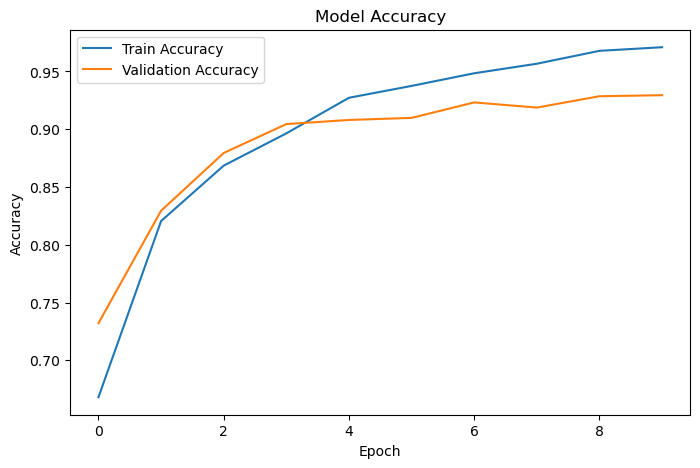

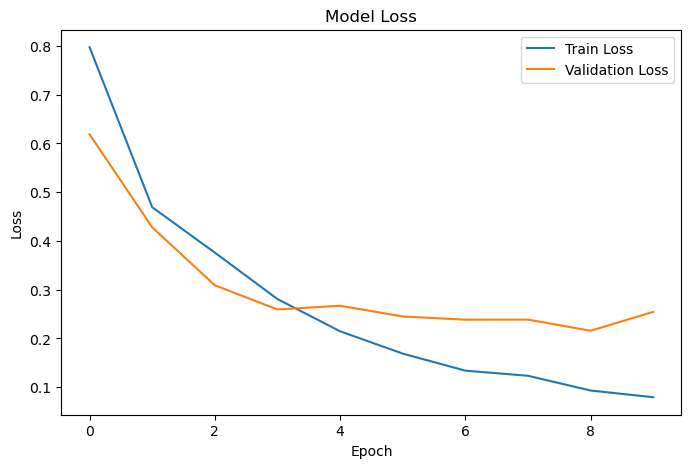

In [7]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history1.history['accuracy'], label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step


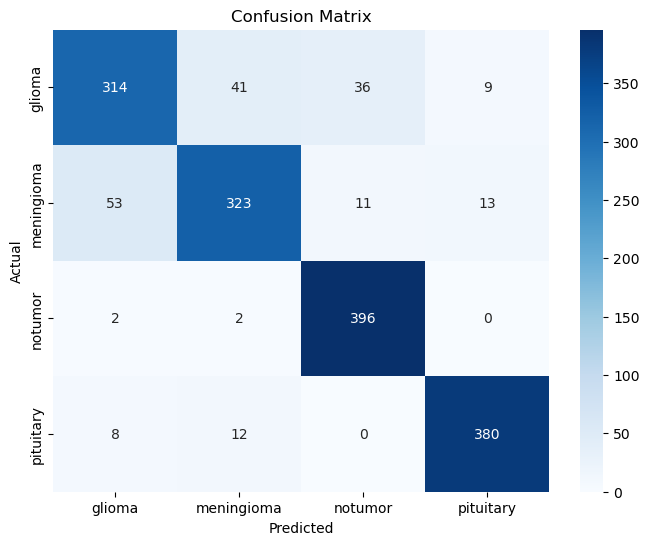

In [8]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Reset generator
test_generator.reset()

# Predict
pred = model1.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.83      0.79      0.81       400
  meningioma       0.85      0.81      0.83       400
     notumor       0.89      0.99      0.94       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model2 = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(128,activation='relu'),
    Dropout(0.3),

    Dense(4,activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

C:\Users\KIIT0001\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,550,340 (24.99 MB)

 Trainable params: 6,549,892 (24.99 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
history2 = model2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 121s 828ms/step - accuracy: 0.5118 - loss: 2.6285 - val_accuracy: 0.2500 - val_loss: 4.4418
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 135s 965ms/step - accuracy: 0.5667 - loss: 1.1017 - val_accuracy: 0.2848 - val_loss: 3.2162
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.5737 - loss: 1.0583 - val_accuracy: 0.4830 - val_loss: 1.1922
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.6125 - loss: 0.9670 - val_accuracy: 0.6598 - val_loss: 0.9978
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 132s 938ms/step - accuracy: 0.6453 - loss: 0.8967 - val_accuracy: 0.7857 - val_loss: 0.5794
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 136s 971ms/step - accuracy: 0.6737 - loss: 0.8522 - val_accuracy: 0.8000 - val_loss: 0.5894
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 130s 929ms/step - accuracy: 0.6877 - loss: 0.7907 - val_accuracy: 0.7964 - val_loss: 0.5329
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.6955 - loss: 0.

In [12]:
test_loss2, test_acc2 = model2.evaluate(test_generator)

print("Model 2 Accuracy:", test_acc2)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 188ms/step - accuracy: 0.5006 - loss: 3.5723
Model 2 Accuracy: 0.5006250143051147


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

In [14]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model3 = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history3 = model3.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 62s 381ms/step - accuracy: 0.7879 - loss: 0.5592 - val_accuracy: 0.8848 - val_loss: 0.3204
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 50s 353ms/step - accuracy: 0.8732 - loss: 0.3376 - val_accuracy: 0.9089 - val_loss: 0.2600
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - accuracy: 0.8946 - loss: 0.2812 - val_accuracy: 0.9152 - val_loss: 0.2322
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 51s 364ms/step - accuracy: 0.9047 - loss: 0.2444 - val_accuracy: 0.9232 - val_loss: 0.2148
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 346ms/step - accuracy: 0.9252 - loss: 0.2013 - val_accuracy: 0.9232 - val_loss: 0.2163
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - accuracy: 0.9252 - loss: 0.1892 - val_accuracy: 0.9214 - val_loss: 0.1993
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 47s 335ms/step - accuracy: 0.9342 - loss: 0.1820 - val_accuracy: 0.9348 - val_loss: 0.1828
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 46s 326ms/step - accuracy: 0.9415 - loss: 0

In [17]:
test_loss3, test_acc3 = model3.evaluate(test_generator)

print("Model 3 Accuracy:", test_acc3)

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 245ms/step - accuracy: 0.8956 - loss: 0.5461
Model 3 Accuracy: 0.8956249952316284


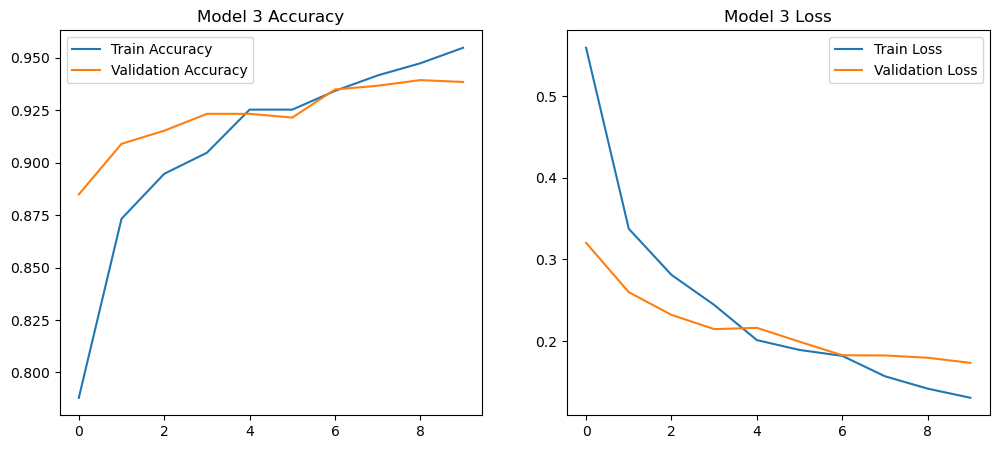

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history3.history['accuracy'], label='Train Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 3 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history3.history['loss'], label='Train Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')
plt.title('Model 3 Loss')
plt.legend()

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 421ms/step


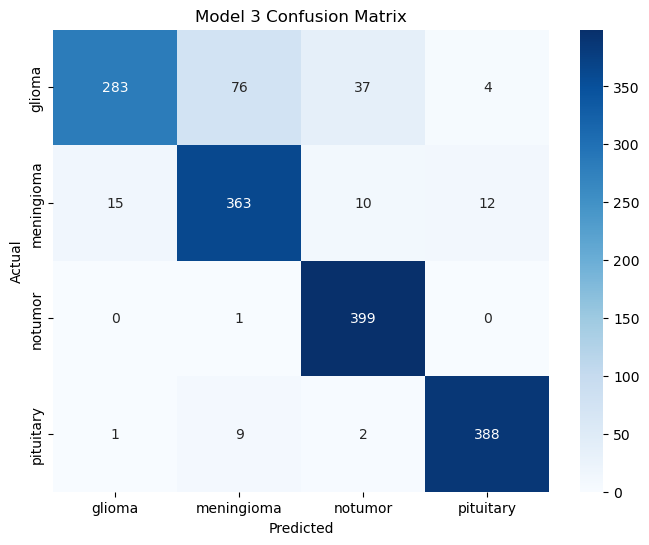

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Reset generator
test_generator.reset()

# Predict using Model 3
pred = model3.predict(test_generator)

pred_classes = np.argmax(pred, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 3 Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.95      0.71      0.81       400
  meningioma       0.81      0.91      0.86       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.96      0.97      0.97       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg       0.90      0.90      0.89      1600



In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "CNN + BatchNormalization",
        "MobileNetV2 Transfer Learning"
    ],
    "Test Accuracy": [
        test_accuracy,
        test_acc2,
        test_acc3
    ]
})

results

,Model,Test Accuracy
0,Basic CNN,0.883125
1,CNN + BatchNormalization,0.500625
2,MobileNetV2 Transfer Learning,0.895625


In [22]:
best = results.loc[results["Test Accuracy"].idxmax()]

print(best)

Model            MobileNetV2 Transfer Learning
Test Accuracy                         0.895625
Name: 2, dtype: object


In [23]:
model3.save("brain_tumor_model.keras")

print("Model saved successfully!")

Model saved successfully!


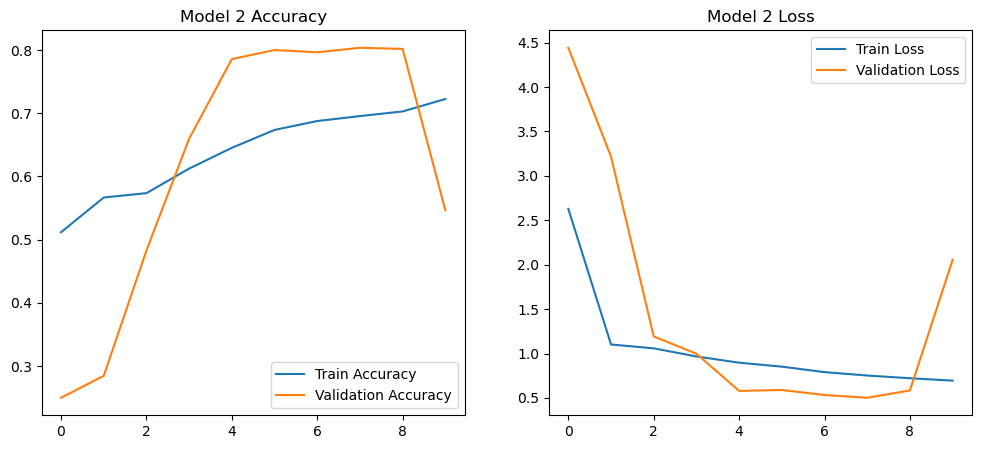

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Model 2 Loss')
plt.legend()

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 596ms/step


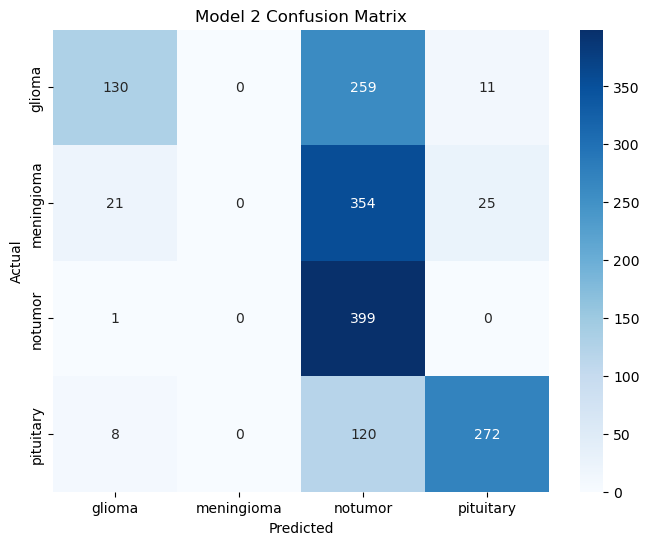

              precision    recall  f1-score   support

      glioma       0.81      0.33      0.46       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.35      1.00      0.52       400
   pituitary       0.88      0.68      0.77       400

    accuracy                           0.50      1600
   macro avg       0.51      0.50      0.44      1600
weighted avg       0.51      0.50      0.44      1600



C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\KIIT0001\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict using Model 2
predictions2 = model2.predict(test_generator)

pred_classes2 = np.argmax(predictions2, axis=1)
true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm2 = confusion_matrix(true_classes, pred_classes2)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Model 2 Confusion Matrix")
plt.show()

# Classification Report
print(classification_report(
    true_classes,
    pred_classes2,
    target_names=class_names
))